# Two-Stage XGBoost Pipeline — Evaluation

Mirrors the structure of `pipeline_eval.ipynb` for direct comparison with the CNN pipeline.

Stage 1: XGBoost structure classifier (Decks / Pavements / Walls)  
Stage 2: Per-structure XGBoost binary defect classifier  

Primary metric: Recall. Secondary: confusion matrix, ROC-AUC, F1.  
Features are 1280-dim MobileNetV2 `GlobalAveragePooling2D` embeddings cached in `features_test.npy`.  
SHAP values replace Grad-CAM for interpretability (no spatial features in tree models).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import datetime
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
)

STRUCTURES = ['Decks', 'Pavements', 'Walls']

## Load Models, Thresholds & Splits

In [ ]:
with open('models/xgb/xgb_structure_model.pkl', 'rb') as f:
    xgb_struct = pickle.load(f)

defect_models = {}
for struct in STRUCTURES:
    with open(f'models/xgb/xgb_defect_{struct.lower()}.pkl', 'rb') as f:
        defect_models[struct] = pickle.load(f)

with open('models/xgb/xgb_thresholds.json') as f:
    thresholds = json.load(f)

df_test = pd.read_csv('splits/test_split.csv')
df_val  = pd.read_csv('splits/val_split.csv')

X_test = np.load('features/features_test.npy')
X_val  = np.load('features/features_val.npy')

print('Thresholds:', thresholds)
print(f'\nTest set: {len(df_test):,} images')
print(df_test.groupby(['structure', 'label']).size().unstack(fill_value=0))

## Stage 1 Evaluation — Structure Classifier

Structure classifier  test accuracy: 0.908
  Decks recall: 0.821
  Pavements recall: 0.961
  Walls recall: 0.911


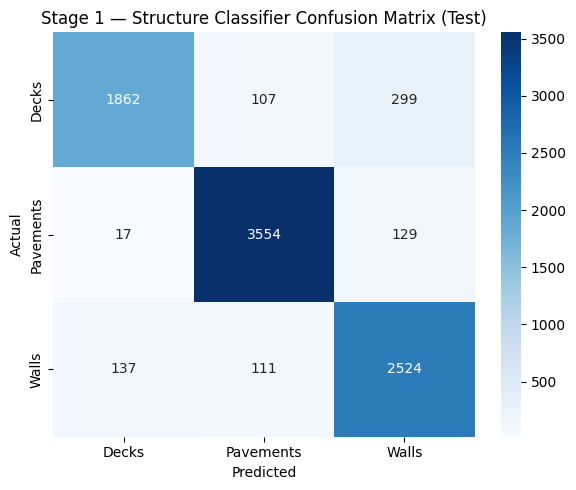

In [3]:
s1_preds = xgb_struct.predict(X_test)
s1_true  = df_test['structure_idx'].values

cm_s1 = confusion_matrix(s1_true, s1_preds)
acc_s1 = (s1_preds == s1_true).mean()
per_class_recall = cm_s1.diagonal() / cm_s1.sum(axis=1)

print(f'Structure classifier  test accuracy: {acc_s1:.3f}')
for i, struct in enumerate(STRUCTURES):
    print(f'  {struct} recall: {per_class_recall[i]:.3f}')

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_s1, annot=True, fmt='d', cmap='Blues',
    xticklabels=STRUCTURES, yticklabels=STRUCTURES,
)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Stage 1 — Structure Classifier Confusion Matrix (Test)')
plt.tight_layout(); plt.show()

## Stage 2 Evaluation — Per-Structure Defect Models

Decks: recall=0.461  precision=0.432  F1=0.446  AUC=0.756  (threshold=0.25)  FN=171


Pavements: recall=0.428  precision=0.248  F1=0.314  AUC=0.721  (threshold=0.3)  FN=218
Walls: recall=0.529  precision=0.373  F1=0.437  AUC=0.684  (threshold=0.25)  FN=302


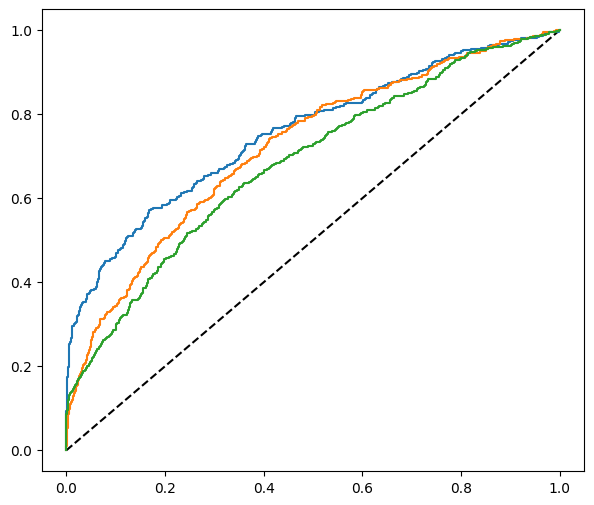

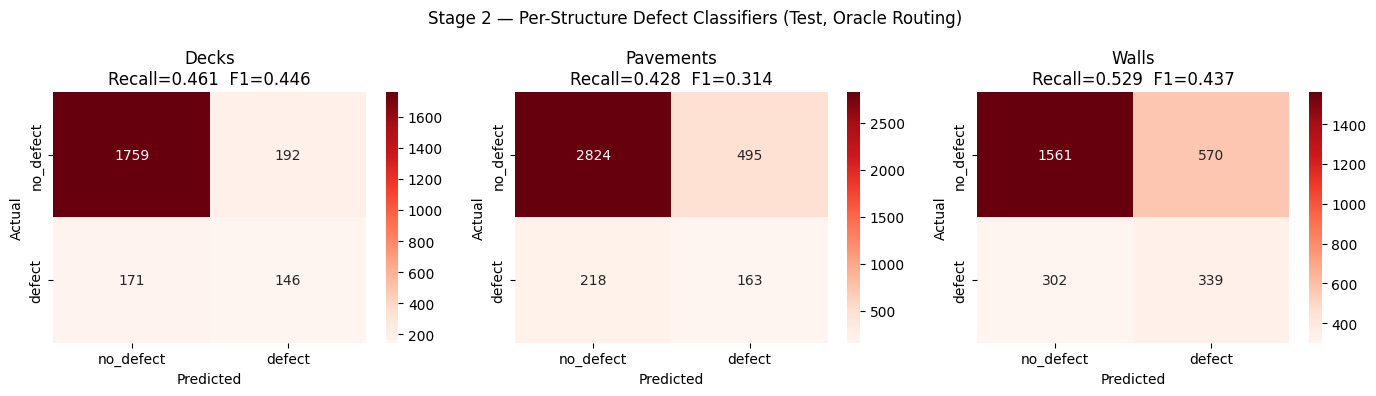

<Figure size 640x480 with 0 Axes>

In [4]:
results = {}

fig_cm, axes_cm = plt.subplots(1, 3, figsize=(14, 4))
fig_roc, ax_roc = plt.subplots(figsize=(7, 6))
ax_roc.plot([0, 1], [0, 1], 'k--', label='Random')

for i, struct in enumerate(STRUCTURES):
    mask = (df_test['structure'] == struct).values
    X_s  = X_test[mask]
    y_s  = df_test.loc[mask, 'defect_idx'].values
    t    = thresholds[struct]

    probs = defect_models[struct].predict_proba(X_s)[:, 1]
    preds = (probs >= t).astype(int)

    rec  = recall_score(y_s, preds, zero_division=0)
    prec = precision_score(y_s, preds, zero_division=0)
    f1   = f1_score(y_s, preds, zero_division=0)
    auc  = roc_auc_score(y_s, probs)
    cm   = confusion_matrix(y_s, preds)

    results[struct] = dict(
        recall=rec, precision=prec, f1=f1, roc_auc=auc,
        confusion_matrix=cm, threshold=t,
        probs=probs, y_true=y_s, y_pred=preds,
    )

    tn, fp, fn, tp = cm.ravel()
    print(f'{struct}: recall={rec:.3f}  precision={prec:.3f}  F1={f1:.3f}  '
          f'AUC={auc:.3f}  (threshold={t})  FN={fn}')

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Reds', ax=axes_cm[i],
        xticklabels=['no_defect', 'defect'],
        yticklabels=['no_defect', 'defect'],
    )
    axes_cm[i].set_title(f'{struct}\nRecall={rec:.3f}  F1={f1:.3f}')
    axes_cm[i].set_xlabel('Predicted')
    axes_cm[i].set_ylabel('Actual')

    fpr, tpr, _ = roc_curve(y_s, probs)
    ax_roc.plot(fpr, tpr, label=f'{struct} (AUC={auc:.3f})')

fig_cm.suptitle('Stage 2 — Per-Structure Defect Classifiers (Test, Oracle Routing)')
fig_cm.tight_layout()
plt.figure(fig_cm.number); plt.show()

ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('Stage 2 — ROC Curves (Oracle Routing)')
ax_roc.legend()
fig_roc.tight_layout()
plt.figure(fig_roc.number); plt.show()

## End-to-End Pipeline Evaluation

Simulates the full two-stage pipeline: Stage 1 predicts the structure type, then each image is routed to the corresponding Stage 2 defect model.

**Oracle recall** uses the ground-truth structure label for routing — this isolates Stage 2 performance from Stage 1 errors.  
**Recall drop** = oracle recall − E2E recall quantifies how much Stage 1 misrouting costs.

=== End-to-End Pipeline (XGBoost) ===
  Recall:    0.457
  Precision: 0.328
  F1:        0.382
  ROC-AUC:   0.719

Oracle recall (true routing):       0.484
Recall drop due to Stage 1 errors:  0.027


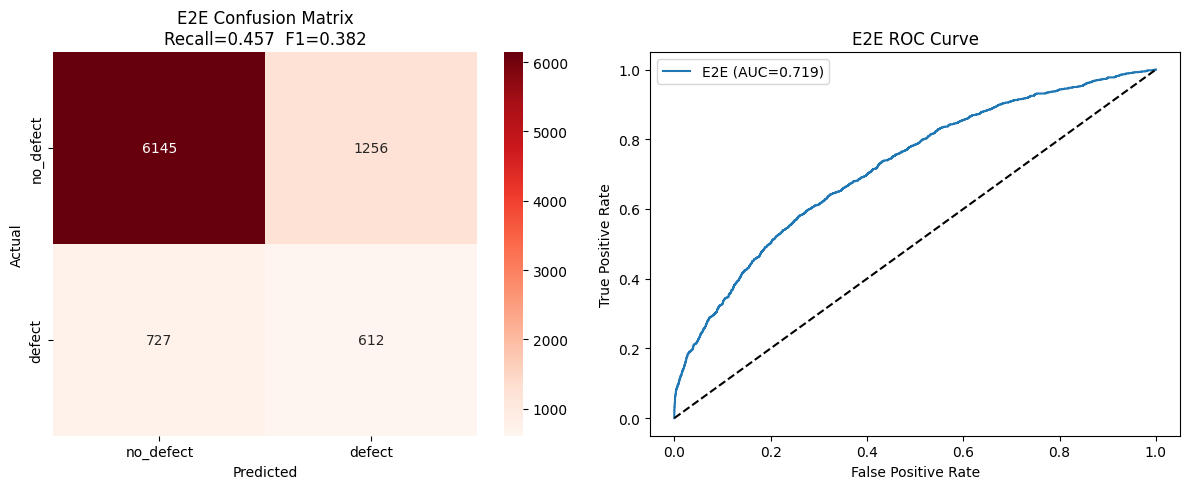

In [5]:
y_defect_true = df_test['defect_idx'].values

# E2E: route by Stage 1 prediction
e2e_struct_preds = xgb_struct.predict(X_test)
e2e_probs = np.zeros(len(df_test))
e2e_preds = np.zeros(len(df_test), dtype=int)

for i, struct in enumerate(STRUCTURES):
    mask = e2e_struct_preds == i
    if mask.sum() == 0:
        continue
    t = thresholds[struct]
    probs_s = defect_models[struct].predict_proba(X_test[mask])[:, 1]
    e2e_probs[mask] = probs_s
    e2e_preds[mask] = (probs_s >= t).astype(int)

e2e_recall = recall_score(y_defect_true, e2e_preds, zero_division=0)
e2e_prec   = precision_score(y_defect_true, e2e_preds, zero_division=0)
e2e_f1     = f1_score(y_defect_true, e2e_preds, zero_division=0)
e2e_auc    = roc_auc_score(y_defect_true, e2e_probs)
e2e_cm     = confusion_matrix(y_defect_true, e2e_preds)

# Oracle: route by true structure label
oracle_probs = np.zeros(len(df_test))
oracle_preds = np.zeros(len(df_test), dtype=int)

for i, struct in enumerate(STRUCTURES):
    mask = df_test['structure_idx'].values == i
    if mask.sum() == 0:
        continue
    t = thresholds[struct]
    probs_s = defect_models[struct].predict_proba(X_test[mask])[:, 1]
    oracle_probs[mask] = probs_s
    oracle_preds[mask] = (probs_s >= t).astype(int)

oracle_recall = recall_score(y_defect_true, oracle_preds, zero_division=0)

print('=== End-to-End Pipeline (XGBoost) ===')
print(f'  Recall:    {e2e_recall:.3f}')
print(f'  Precision: {e2e_prec:.3f}')
print(f'  F1:        {e2e_f1:.3f}')
print(f'  ROC-AUC:   {e2e_auc:.3f}')
print(f'\nOracle recall (true routing):       {oracle_recall:.3f}')
print(f'Recall drop due to Stage 1 errors:  {oracle_recall - e2e_recall:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    e2e_cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
    xticklabels=['no_defect', 'defect'],
    yticklabels=['no_defect', 'defect'],
)
axes[0].set_title(f'E2E Confusion Matrix\nRecall={e2e_recall:.3f}  F1={e2e_f1:.3f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_defect_true, e2e_probs)
axes[1].plot(fpr, tpr, label=f'E2E (AUC={e2e_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('E2E ROC Curve')
axes[1].legend()

plt.tight_layout(); plt.show()

## Feature Importance

XGBoost has no spatial attention mechanism, so Grad-CAM does not apply. XGBoost's built-in `feature_importances_` (gain-based) serves the analogous interpretability role: it shows which of the 1280 embedding dimensions most reduce impurity across all trees, indicating what information the backbone encoded that XGBoost found most discriminative for each structure type.

**Note:** Features are abstract CNN embedding dimensions — they do not map directly to pixel regions.

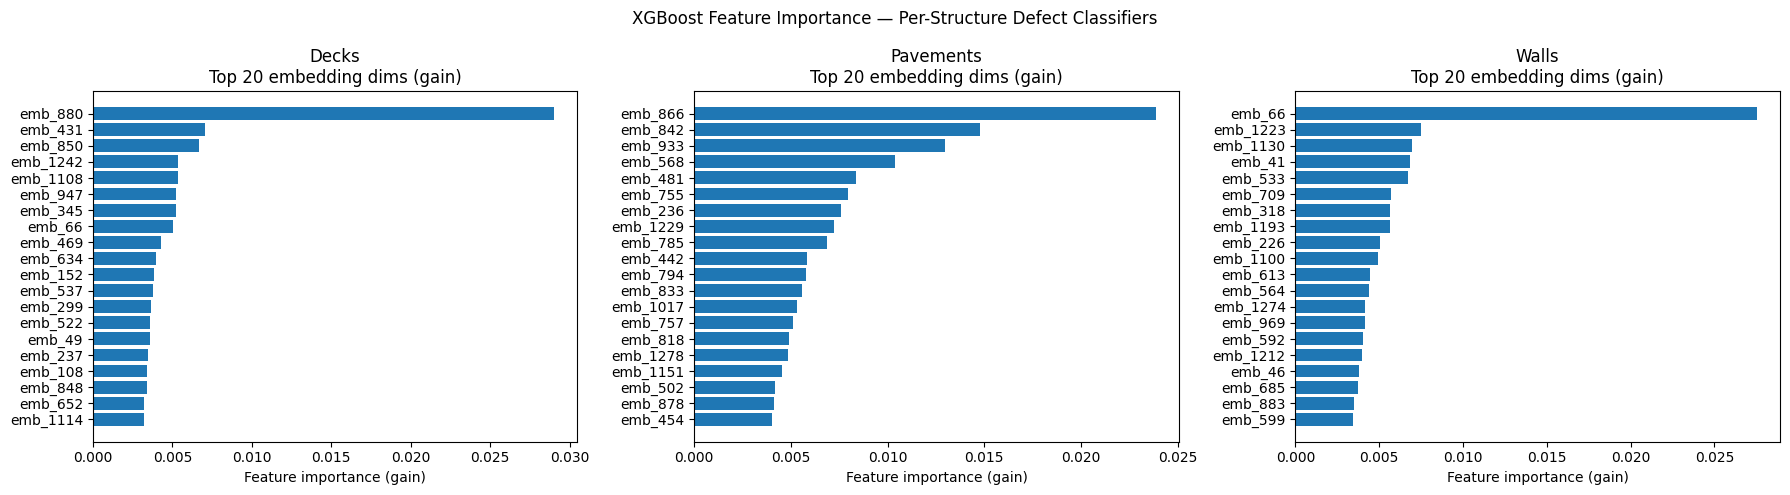

In [6]:
TOP_N = 20

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, struct in enumerate(STRUCTURES):
    model = defect_models[struct]
    importances = model.feature_importances_  # gain-based, shape (1280,)

    top_idx = np.argsort(importances)[-TOP_N:][::-1]
    top_vals = importances[top_idx]
    top_names = [f'emb_{j}' for j in top_idx]

    axes[i].barh(top_names[::-1], top_vals[::-1])
    axes[i].set_title(f'{struct}\nTop {TOP_N} embedding dims (gain)')
    axes[i].set_xlabel('Feature importance (gain)')

plt.suptitle('XGBoost Feature Importance — Per-Structure Defect Classifiers')
plt.tight_layout()
plt.show()

## Summary Report

In [ ]:
rows = []
for struct in STRUCTURES:
    r  = results[struct]
    cm = r['confusion_matrix']
    tn, fp, fn, tp = cm.ravel()
    rows.append({
        'Structure': struct,
        'Threshold': r['threshold'],
        'Recall':    round(r['recall'],    3),
        'Precision': round(r['precision'], 3),
        'F1':        round(r['f1'],        3),
        'ROC-AUC':   round(r['roc_auc'],   3),
        'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
    })

df_summary = pd.DataFrame(rows)
print('=== Stage 2 Results (Oracle Routing) ===')
print(df_summary.to_string(index=False))
print()
print('=== End-to-End Pipeline ===')
print(f'  Recall={e2e_recall:.3f}  Precision={e2e_prec:.3f}  '
      f'F1={e2e_f1:.3f}  ROC-AUC={e2e_auc:.3f}')
print(f'  Oracle recall={oracle_recall:.3f}  '
      f'Recall drop={oracle_recall - e2e_recall:.3f}')
print(f'  False Negatives (missed defects): {e2e_cm[1, 0]}')

# Write reports/xgb_pipeline_report.md
Path('reports').mkdir(exist_ok=True)
n_train = len(pd.read_csv('splits/train_split.csv'))
n_val   = len(pd.read_csv('splits/val_split.csv'))
n_test  = len(df_test)

lines = [
    '# XGBoost Pipeline Report\n\n',
    f'*Generated: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M")}*\n\n',
    '## Assumptions & Limitations\n\n',
    '- Features are 1280-dim MobileNetV2 GlobalAveragePooling2D embeddings '
    '(frozen backbone, no fine-tuning).\n',
    '- XGBoost has no spatial attention; feature importance shows embedding-dimension '
    'importance, not pixel-level localisation.\n',
    '- Splits are identical to the CNN pipeline '
    '(`splits/train_split.csv`, `splits/val_split.csv`, `splits/test_split.csv`).\n\n',
    '## Data Split\n\n',
    '| Split | Images |\n|---|---|\n',
    f'| Train | {n_train:,} |\n',
    f'| Val   | {n_val:,} |\n',
    f'| Test  | {n_test:,} |\n\n',
    '## Stage 1 — Structure Classifier\n\n',
    f'Test accuracy: **{acc_s1:.3f}**\n\n',
    '## Stage 2 — Per-Structure Defect Classifiers (Oracle Routing)\n\n',
    df_summary.to_markdown(index=False) + '\n\n',
    '## End-to-End Pipeline\n\n',
    '| Metric | Value |\n|---|---|\n',
    f'| Recall | {e2e_recall:.3f} |\n',
    f'| Precision | {e2e_prec:.3f} |\n',
    f'| F1 | {e2e_f1:.3f} |\n',
    f'| ROC-AUC | {e2e_auc:.3f} |\n',
    f'| Oracle Recall | {oracle_recall:.3f} |\n',
    f'| Recall Drop | {oracle_recall - e2e_recall:.3f} |\n',
    f'| False Negatives | {e2e_cm[1, 0]} |\n\n',
    '## Tuned Thresholds\n\n',
]
for struct, t in thresholds.items():
    lines.append(f'- {struct}: {t}\n')
lines.append('\n---\n*XGBoost + MobileNetV2 feature extraction pipeline*\n')

with open('reports/xgb_pipeline_report.md', 'w') as f:
    f.writelines(lines)
print('\nSaved reports/xgb_pipeline_report.md')